**Import required Libraries**

In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\manik\Downloads\archive (1).zip")

print("Shape:", df.shape)
print(df.head())

Shape: (1035, 16)
      sex  age  cp  resting_BP  chol  fbs  restecg  thalach   exang  oldpeak  \
0    male   65   0         130   254    0        0       147      0      1.4   
1    male   53   0         140   261    0        0       186      1      0.0   
2    male   50   0         122   222    0        0       186      0      0.0   
3  female   47   1         112   160    0        1       138      0      0.0   
4    male   47   0         142   309    0        0       147      1      0.0   

   slope  ca  thal  Max Heart Rate Reserve  Heart Disease Risk Score  target  
0      1   1     3                      10                     11.44       0  
1      2   0     2                     -17                     13.51       1  
2      2   0     2                     -14                      9.46       1  
3      1   0     2                      37                      8.34       1  
4      1   3     3                      28                     13.43       0  


In [2]:
# Remove extra spaces from column names
df.columns = df.columns.str.strip()

print(df.columns)

Index(['sex', 'age', 'cp', 'resting_BP', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'Max Heart Rate Reserve',
       'Heart Disease Risk Score', 'target'],
      dtype='object')


In [3]:
df['sex'] = df['sex'].map({'male': 1, 'female': 0})

In [4]:
X = df.drop("target", axis=1)
y = df["target"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1035, 15)
Target shape: (1035,)


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
X = df.drop(["target", "Heart Disease Risk Score"], axis=1)
y = df["target"]

In [8]:
df.columns = df.columns.str.strip()
df['sex'] = df['sex'].map({'male': 1, 'female': 0})

X = df.drop(["target", "Heart Disease Risk Score"], axis=1)
y = df["target"]

In [9]:
# ==============================
# 7. Logistic Regression
# ==============================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

lr_train_pred = lr.predict(X_train_scaled)
lr_test_pred = lr.predict(X_test_scaled)

print("Logistic Train Accuracy:", accuracy_score(y_train, lr_train_pred))
print("Logistic Test Accuracy:", accuracy_score(y_test, lr_test_pred))

print("\nClassification Report:\n", classification_report(y_test, lr_test_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, lr_test_pred))

Logistic Train Accuracy: 0.8635265700483091
Logistic Test Accuracy: 0.8115942028985508

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.74      0.79       101
           1       0.78      0.88      0.83       106

    accuracy                           0.81       207
   macro avg       0.82      0.81      0.81       207
weighted avg       0.82      0.81      0.81       207


Confusion Matrix:
 [[75 26]
 [13 93]]


In [10]:
# ==============================
# 8. Random Forest
# ==============================

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_train_pred = rf.predict(X_train)
rf_test_pred = rf.predict(X_test)

print("RF Train Accuracy:", accuracy_score(y_train, rf_train_pred))
print("RF Test Accuracy:", accuracy_score(y_test, rf_test_pred))

print("\nClassification Report:\n", classification_report(y_test, rf_test_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, rf_test_pred))

RF Train Accuracy: 1.0
RF Test Accuracy: 0.9951690821256038

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00       101
           1       0.99      1.00      1.00       106

    accuracy                           1.00       207
   macro avg       1.00      1.00      1.00       207
weighted avg       1.00      1.00      1.00       207


Confusion Matrix:
 [[100   1]
 [  0 106]]


In [11]:
# ==============================
# 9. XGBoost
# ==============================

from xgboost import XGBClassifier

xgb = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_train_pred = xgb.predict(X_train)
xgb_test_pred = xgb.predict(X_test)

print("XGB Train Accuracy:", accuracy_score(y_train, xgb_train_pred))
print("XGB Test Accuracy:", accuracy_score(y_test, xgb_test_pred))

print("\nClassification Report:\n", classification_report(y_test, xgb_test_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, xgb_test_pred))

XGB Train Accuracy: 1.0
XGB Test Accuracy: 0.9903381642512077

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       101
           1       0.99      0.99      0.99       106

    accuracy                           0.99       207
   macro avg       0.99      0.99      0.99       207
weighted avg       0.99      0.99      0.99       207


Confusion Matrix:
 [[100   1]
 [  1 105]]


In [12]:
# ==============================
# 10. Cross Validation
# ==============================

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf, X, y, cv=5)

print("Cross Validation Scores:", cv_scores)
print("Average CV Accuracy:", cv_scores.mean())

Cross Validation Scores: [1.         1.         1.         1.         0.97584541]
Average CV Accuracy: 0.9951690821256038


In [13]:
# ==============================
# 11. Hyperparameter Tuning
# ==============================

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

best_model = grid.best_estimator_

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Score: 0.9770500182548375


Final Test Accuracy: 0.9903381642512077

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       101
           1       0.99      0.99      0.99       106

    accuracy                           0.99       207
   macro avg       0.99      0.99      0.99       207
weighted avg       0.99      0.99      0.99       207


Confusion Matrix:
 [[100   1]
 [  1 105]]


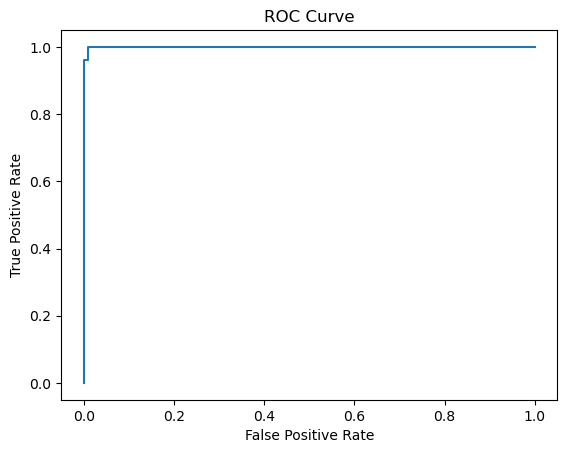

ROC AUC Score: 0.9996263777321128


In [14]:
# ==============================
# 12. Final Model Evaluation
# ==============================

from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

print("Final Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

print("ROC AUC Score:", roc_auc_score(y_test, y_prob))

In [15]:
!pip install shap

In [16]:
import shap

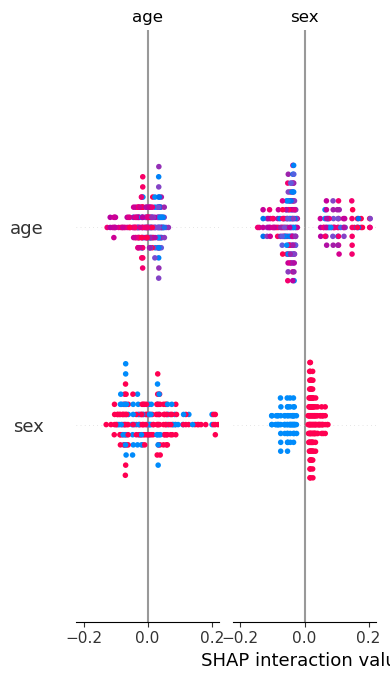

In [18]:
shap.summary_plot(shap_values, X_test)

In [19]:
# ==============================
# 14. Save Model & Scaler
# ==============================

import pickle

pickle.dump(best_model, open("heart_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

print("Model Saved Successfully!")

Model Saved Successfully!
